In [128]:
import gdown

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [130]:
pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")

downloading dataset from gdrive

In [131]:
# Download a file
url = "https://drive.google.com/file/d/1xZo782T4EfnkC0BmCwJTb0DZYYHoOXKm/view"
output = "dataset.csv"
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1xZo782T4EfnkC0BmCwJTb0DZYYHoOXKm
To: n:\unified mentor\System Capacity & Care Load Analytics\dataset.csv
100%|██████████| 33.0k/33.0k [00:01<00:00, 29.9kB/s]


'dataset.csv'

Load Dataset

In [132]:
# Load dataset

df = pd.read_csv("dataset.csv")

# Display first rows

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [133]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 69.5 KB


In [134]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


renaming columns

In [135]:
df.rename(columns={

    'Children apprehended and placed in CBP custody':
    'CBP_Intake',

    'Children in CBP custody':
    'CBP_Custody',

    'Children transferred out of CBP custody':
    'Transferred_to_HHS',

    'Children in HHS Care':
    'HHS_Care',

    'Children discharged from HHS Care':
    'HHS_Discharged'

}, inplace=True)

In [136]:
df.head()

,Date,Children apprehended and placed in CBP custody*,CBP_Custody,Transferred_to_HHS,HHS_Care,HHS_Discharged
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


missing value

In [137]:
missing_values = df.isnull().sum()
missing_values

Date                                               450
Children apprehended and placed in CBP custody*    450
CBP_Custody                                        450
Transferred_to_HHS                                 450
HHS_Care                                           450
HHS_Discharged                                     450
dtype: int64

In [138]:
# dropping null values 
df.dropna(how='all', inplace=True)

In [139]:
df.isnull().sum()   

Date                                               0
Children apprehended and placed in CBP custody*    0
CBP_Custody                                        0
Transferred_to_HHS                                 0
HHS_Care                                           0
HHS_Discharged                                     0
dtype: int64

Duplicate Record Detection

In [140]:
df.duplicated().sum()

np.int64(0)

In [141]:
# convert date column 
df['Date'] = pd.to_datetime(df['Date'])
# convert hhs care column to numeric 
df["HHS_Care"] = df['HHS_Care'].str.replace(',', '').astype(int)



In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   CBP_Custody                                      720 non-null    float64       
 3   Transferred_to_HHS                               720 non-null    float64       
 4   HHS_Care                                         720 non-null    int64         
 5   HHS_Discharged                                   720 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 33.9 KB


In [143]:
# Sort dataset chronologically

df = df.sort_values(by='Date')

In [146]:
df.head()

,Date,Children apprehended and placed in CBP custody*,CBP_Custody,Transferred_to_HHS,HHS_Care,HHS_Discharged
719,2023-01-12,33.0,53.0,34.0,6566,436.0
718,2023-01-22,32.0,49.0,39.0,7122,227.0
717,2023-01-23,32.0,50.0,39.0,7280,181.0
716,2023-01-24,47.0,42.0,47.0,7433,175.0
715,2023-01-25,20.0,22.0,41.0,7538,180.0


In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 719 to 0
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   CBP_Custody                                      720 non-null    float64       
 3   Transferred_to_HHS                               720 non-null    float64       
 4   HHS_Care                                         720 non-null    int64         
 5   HHS_Discharged                                   720 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 33.9 KB


# Data validation check

Transfers Should Not Exceed CBP Custody

In [148]:
invalid_transfer = df[
    df['Transferred_to_HHS']
    >
    df['CBP_Custody']
]

print("Invalid Transfer Records:", invalid_transfer.shape[0])

Invalid Transfer Records: 86


Discharges Should Not Exceed HHS Care

In [149]:
invalid_discharge = df[
    df['HHS_Discharged']
    >
    df['HHS_Care']
]

print("Invalid Discharge Records:", invalid_discharge.shape[0])

Invalid Discharge Records: 0


In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 719 to 0
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   CBP_Custody                                      720 non-null    float64       
 3   Transferred_to_HHS                               720 non-null    float64       
 4   HHS_Care                                         720 non-null    int64         
 5   HHS_Discharged                                   720 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 33.9 KB


Flag Reporting Anomalies

In [151]:
df['Reporting_Anomaly'] = np.where(

    (
        (df['Transferred_to_HHS'] > df['CBP_Custody']) |

        (df['HHS_Discharged'] > df['HHS_Care'])
    ),

    'Anomaly',

    'Valid'
)

In [152]:
df.head()

,Date,Children apprehended and placed in CBP custody*,CBP_Custody,Transferred_to_HHS,HHS_Care,HHS_Discharged,Reporting_Anomaly
719,2023-01-12,33.0,53.0,34.0,6566,436.0,Valid
718,2023-01-22,32.0,49.0,39.0,7122,227.0,Valid
717,2023-01-23,32.0,50.0,39.0,7280,181.0,Valid
716,2023-01-24,47.0,42.0,47.0,7433,175.0,Anomaly
715,2023-01-25,20.0,22.0,41.0,7538,180.0,Anomaly


In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 719 to 0
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   CBP_Custody                                      720 non-null    float64       
 3   Transferred_to_HHS                               720 non-null    float64       
 4   HHS_Care                                         720 non-null    int64         
 5   HHS_Discharged                                   720 non-null    float64       
 6   Reporting_Anomaly                                720 non-null    str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 43.2 KB


In [154]:
df['Reporting_Anomaly'].value_counts()

Reporting_Anomaly
Valid      634
Anomaly     86
Name: count, dtype: int64

# Feature engineering 

Total System Load

(Measures total children under federal care.)

In [155]:
df['Total_System_Load'] = (
    df['CBP_Custody']
    +
    df['HHS_Care']
)

Net Daily Intake

(Measures inflow vs outflow pressure.)

In [156]:
df['Net_Daily_Intake'] = (
    df['Transferred_to_HHS']
    -
    df['HHS_Discharged']
)

Care Load Growth Rate

(Measures day-over-day load growth.)

In [157]:
df['Care_Load_Growth_Rate'] = (
    df['Total_System_Load']
    .pct_change()
) * 100

Backlog Indicator

(Positive values indicate pressure accumulation.)

In [158]:
df['Backlog_Indicator'] = (
    df['Net_Daily_Intake']
    .rolling(window=7)
    .sum()
)

In [159]:
df.head()

,Date,Children apprehended and placed in CBP custody*,CBP_Custody,Transferred_to_HHS,HHS_Care,HHS_Discharged,Reporting_Anomaly,Total_System_Load,Net_Daily_Intake,Care_Load_Growth_Rate,Backlog_Indicator
719,2023-01-12,33.0,53.0,34.0,6566,436.0,Valid,6619.0,-402.0,NaN,NaN
718,2023-01-22,32.0,49.0,39.0,7122,227.0,Valid,7171.0,-188.0,8.339628,NaN
717,2023-01-23,32.0,50.0,39.0,7280,181.0,Valid,7330.0,-142.0,2.217264,NaN
716,2023-01-24,47.0,42.0,47.0,7433,175.0,Anomaly,7475.0,-128.0,1.978172,NaN
715,2023-01-25,20.0,22.0,41.0,7538,180.0,Anomaly,7560.0,-139.0,1.137124,NaN


In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 719 to 0
Data columns (total 11 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   CBP_Custody                                      720 non-null    float64       
 3   Transferred_to_HHS                               720 non-null    float64       
 4   HHS_Care                                         720 non-null    int64         
 5   HHS_Discharged                                   720 non-null    float64       
 6   Reporting_Anomaly                                720 non-null    str           
 7   Total_System_Load                                720 non-null    float64       
 8   Net_Daily_Intake                                 72

# KPI Overview

In [162]:
print("=========== HEALTHCARE KPIs ===========")

print()

print(
    "Average Total System Load:",
    round(df['Total_System_Load'].mean(), 2)
)

print()

print(
    "Average Net Intake Pressure:",
    round(df['Net_Daily_Intake'].mean(), 2)
)

print()

print(
    "Maximum System Load:",
    round(df['Total_System_Load'].max(), 2)
)

print()

print(
    "Average Growth Rate:",
    round(df['Care_Load_Growth_Rate'].mean(), 2),
    "%"
)

=========== HEALTHCARE KPIs ===========

Average Total System Load: 6232.77

Average Net Intake Pressure: -44.74

Maximum System Load: 11762.0

Average Growth Rate: -0.12 %


# Time-Series Trend Analysis

Total System Load Trend

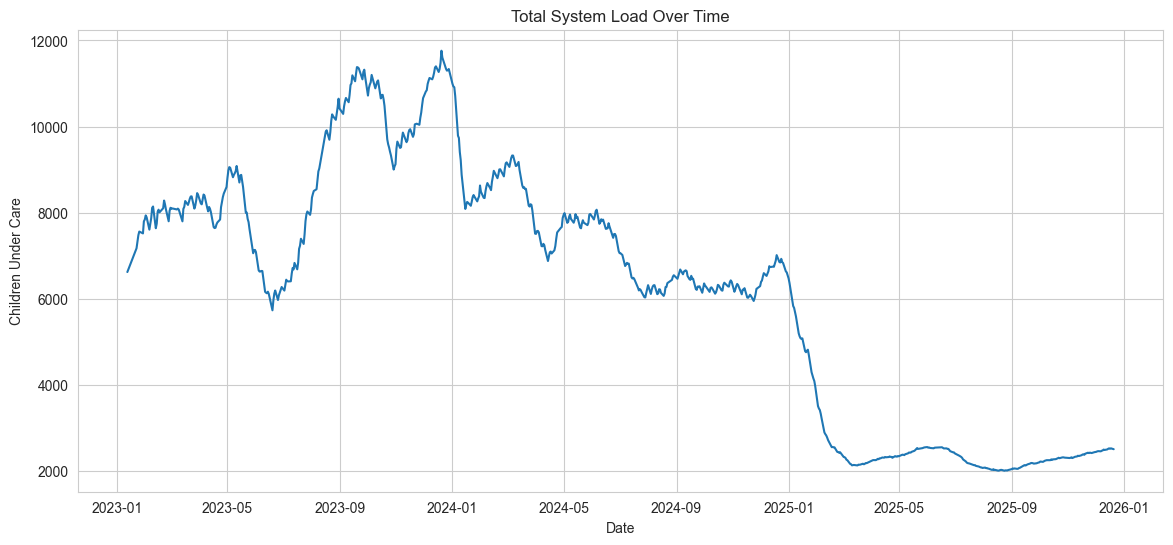

In [163]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Total_System_Load']
)

plt.title("Total System Load Over Time")

plt.xlabel("Date")

plt.ylabel("Children Under Care")

plt.show()

CBP vs HHS Comparison

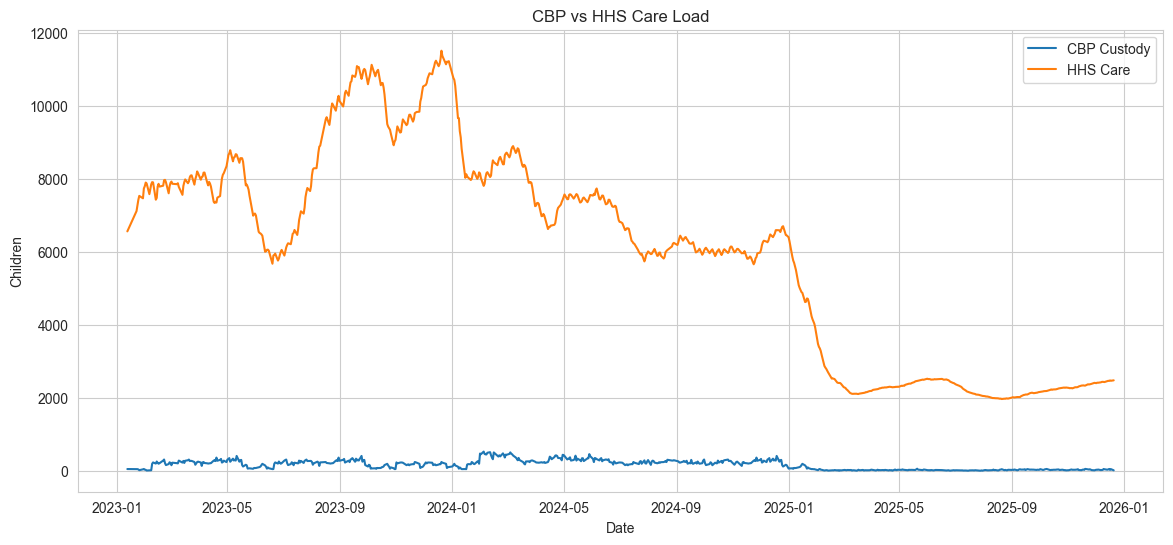

In [164]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['CBP_Custody'],
    label='CBP Custody'
)

plt.plot(
    df['Date'],
    df['HHS_Care'],
    label='HHS Care'
)

plt.title("CBP vs HHS Care Load")

plt.xlabel("Date")

plt.ylabel("Children")

plt.legend()

plt.show()

Daily Intake vs Discharge Analysis

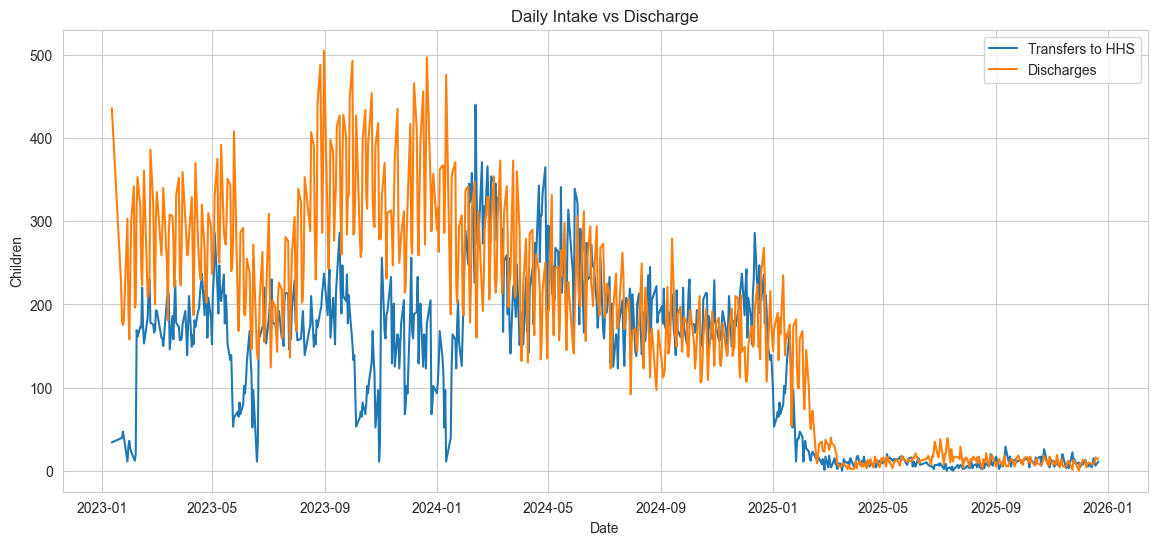

In [165]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Transferred_to_HHS'],
    label='Transfers to HHS'
)

plt.plot(
    df['Date'],
    df['HHS_Discharged'],
    label='Discharges'
)

plt.title("Daily Intake vs Discharge")

plt.xlabel("Date")

plt.ylabel("Children")

plt.legend()

plt.show()

# Rolling Average Analysis

7-Day Rolling Average

In [166]:
df['7Day_Load_Avg'] = (
    df['Total_System_Load']
    .rolling(window=7)
    .mean()
)

14-Day Rolling Average

In [167]:
df['14Day_Load_Avg'] = (
    df['Total_System_Load']
    .rolling(window=14)
    .mean()
)

In [168]:
df.head()

,Date,Children apprehended and placed in CBP custody*,CBP_Custody,Transferred_to_HHS,HHS_Care,HHS_Discharged,Reporting_Anomaly,Total_System_Load,Net_Daily_Intake,Care_Load_Growth_Rate,Backlog_Indicator,7Day_Load_Avg,14Day_Load_Avg
719,2023-01-12,33.0,53.0,34.0,6566,436.0,Valid,6619.0,-402.0,NaN,NaN,NaN,NaN
718,2023-01-22,32.0,49.0,39.0,7122,227.0,Valid,7171.0,-188.0,8.339628,NaN,NaN,NaN
717,2023-01-23,32.0,50.0,39.0,7280,181.0,Valid,7330.0,-142.0,2.217264,NaN,NaN,NaN
716,2023-01-24,47.0,42.0,47.0,7433,175.0,Anomaly,7475.0,-128.0,1.978172,NaN,NaN,NaN
715,2023-01-25,20.0,22.0,41.0,7538,180.0,Anomaly,7560.0,-139.0,1.137124,NaN,NaN,NaN


In [169]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 719 to 0
Data columns (total 13 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   CBP_Custody                                      720 non-null    float64       
 3   Transferred_to_HHS                               720 non-null    float64       
 4   HHS_Care                                         720 non-null    int64         
 5   HHS_Discharged                                   720 non-null    float64       
 6   Reporting_Anomaly                                720 non-null    str           
 7   Total_System_Load                                720 non-null    float64       
 8   Net_Daily_Intake                                 72

Rolling Average Visualization

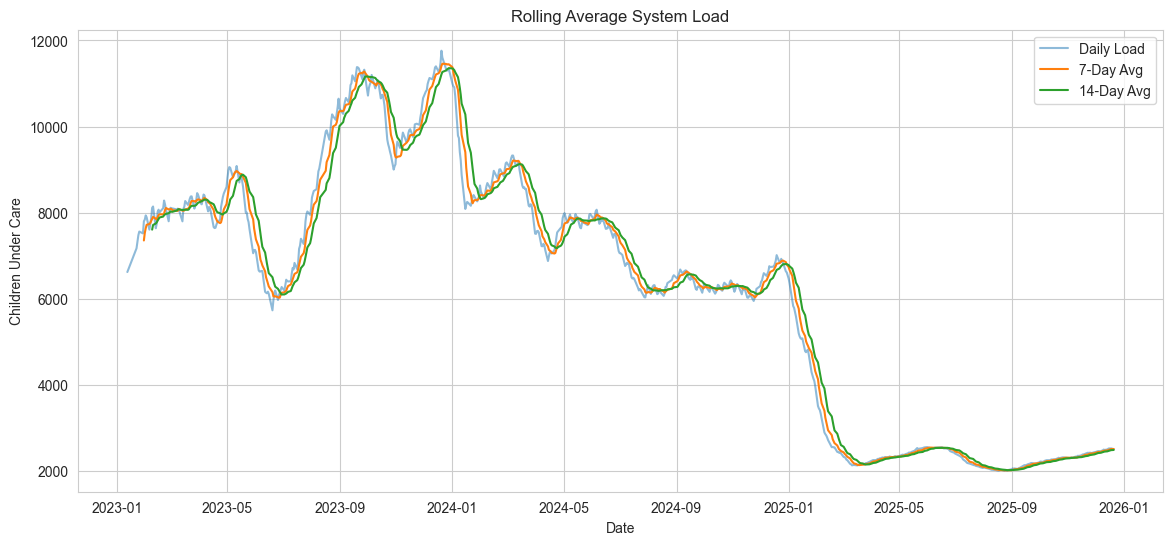

In [170]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Total_System_Load'],
    alpha=0.5,
    label='Daily Load'
)

plt.plot(
    df['Date'],
    df['7Day_Load_Avg'],
    label='7-Day Avg'
)

plt.plot(
    df['Date'],
    df['14Day_Load_Avg'],
    label='14-Day Avg'
)

plt.title("Rolling Average System Load")

plt.xlabel("Date")

plt.ylabel("Children Under Care")

plt.legend()

plt.show()

# Stress & Pressure Detection

Define high-load threshold

In [171]:
high_load_threshold = (
    df['Total_System_Load']
    .quantile(0.90)
)

Flag high stress periods

In [172]:
df['Stress_Level'] = np.where(

    df['Total_System_Load']
    >
    high_load_threshold,

    'High Stress',

    'Normal'
)

In [174]:
df.head()

,Date,Children apprehended and placed in CBP custody*,CBP_Custody,Transferred_to_HHS,HHS_Care,HHS_Discharged,Reporting_Anomaly,Total_System_Load,Net_Daily_Intake,Care_Load_Growth_Rate,Backlog_Indicator,7Day_Load_Avg,14Day_Load_Avg,Stress_Level
719,2023-01-12,33.0,53.0,34.0,6566,436.0,Valid,6619.0,-402.0,NaN,NaN,NaN,NaN,Normal
718,2023-01-22,32.0,49.0,39.0,7122,227.0,Valid,7171.0,-188.0,8.339628,NaN,NaN,NaN,Normal
717,2023-01-23,32.0,50.0,39.0,7280,181.0,Valid,7330.0,-142.0,2.217264,NaN,NaN,NaN,Normal
716,2023-01-24,47.0,42.0,47.0,7433,175.0,Anomaly,7475.0,-128.0,1.978172,NaN,NaN,NaN,Normal
715,2023-01-25,20.0,22.0,41.0,7538,180.0,Anomaly,7560.0,-139.0,1.137124,NaN,NaN,NaN,Normal


Stress Summary

In [175]:
df['Stress_Level'].value_counts()

Stress_Level
Normal         648
High Stress     72
Name: count, dtype: int64

# Volatility Analysis

Daily volatility

In [176]:
df['Load_Volatility'] = (
    df['Total_System_Load']
    .rolling(window=7)
    .std()
)

In [177]:
df.head()

,Date,Children apprehended and placed in CBP custody*,CBP_Custody,Transferred_to_HHS,HHS_Care,HHS_Discharged,Reporting_Anomaly,Total_System_Load,Net_Daily_Intake,Care_Load_Growth_Rate,Backlog_Indicator,7Day_Load_Avg,14Day_Load_Avg,Stress_Level,Load_Volatility
719,2023-01-12,33.0,53.0,34.0,6566,436.0,Valid,6619.0,-402.0,NaN,NaN,NaN,NaN,Normal,NaN
718,2023-01-22,32.0,49.0,39.0,7122,227.0,Valid,7171.0,-188.0,8.339628,NaN,NaN,NaN,Normal,NaN
717,2023-01-23,32.0,50.0,39.0,7280,181.0,Valid,7330.0,-142.0,2.217264,NaN,NaN,NaN,Normal,NaN
716,2023-01-24,47.0,42.0,47.0,7433,175.0,Anomaly,7475.0,-128.0,1.978172,NaN,NaN,NaN,Normal,NaN
715,2023-01-25,20.0,22.0,41.0,7538,180.0,Anomaly,7560.0,-139.0,1.137124,NaN,NaN,NaN,Normal,NaN


In [178]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 719 to 0
Data columns (total 15 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   CBP_Custody                                      720 non-null    float64       
 3   Transferred_to_HHS                               720 non-null    float64       
 4   HHS_Care                                         720 non-null    int64         
 5   HHS_Discharged                                   720 non-null    float64       
 6   Reporting_Anomaly                                720 non-null    str           
 7   Total_System_Load                                720 non-null    float64       
 8   Net_Daily_Intake                                 72

Volatility Visualization

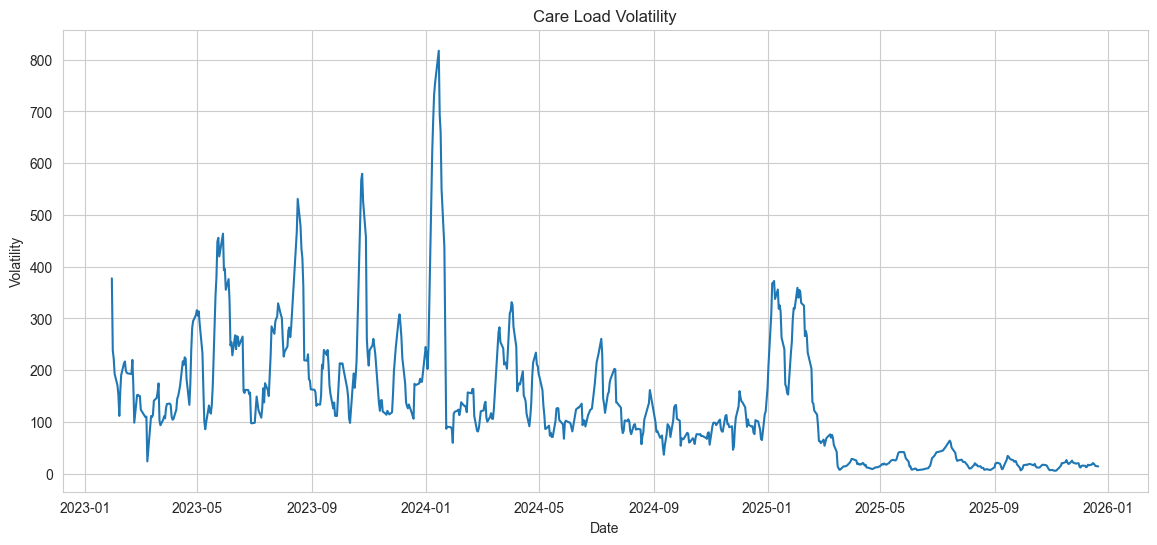

In [179]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Load_Volatility']
)

plt.title("Care Load Volatility")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.show()

# Monthly Trend Analysis

In [183]:
df['Month'] = (
    df['Date']
    .dt
    .to_period('M')
)

In [184]:
df['Month']

719    2023-01
718    2023-01
717    2023-01
716    2023-01
715    2023-01
        ...   
4      2025-12
3      2025-12
2      2025-12
1      2025-12
0      2025-12
Name: Month, Length: 720, dtype: period[M]

Monthly System Load

In [185]:
monthly_load = (
    df.groupby('Month')['Total_System_Load']
    .mean()
)

Visualization

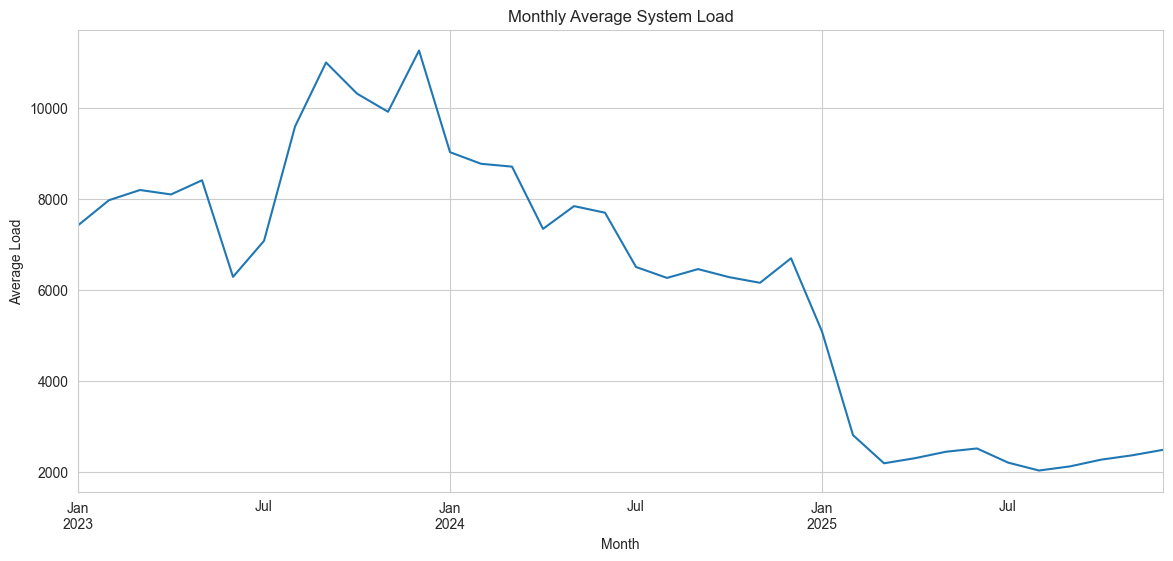

In [186]:
monthly_load.plot(
    figsize=(14,6)
)

plt.title("Monthly Average System Load")

plt.ylabel("Average Load")

plt.show()

# Correlation Analysis

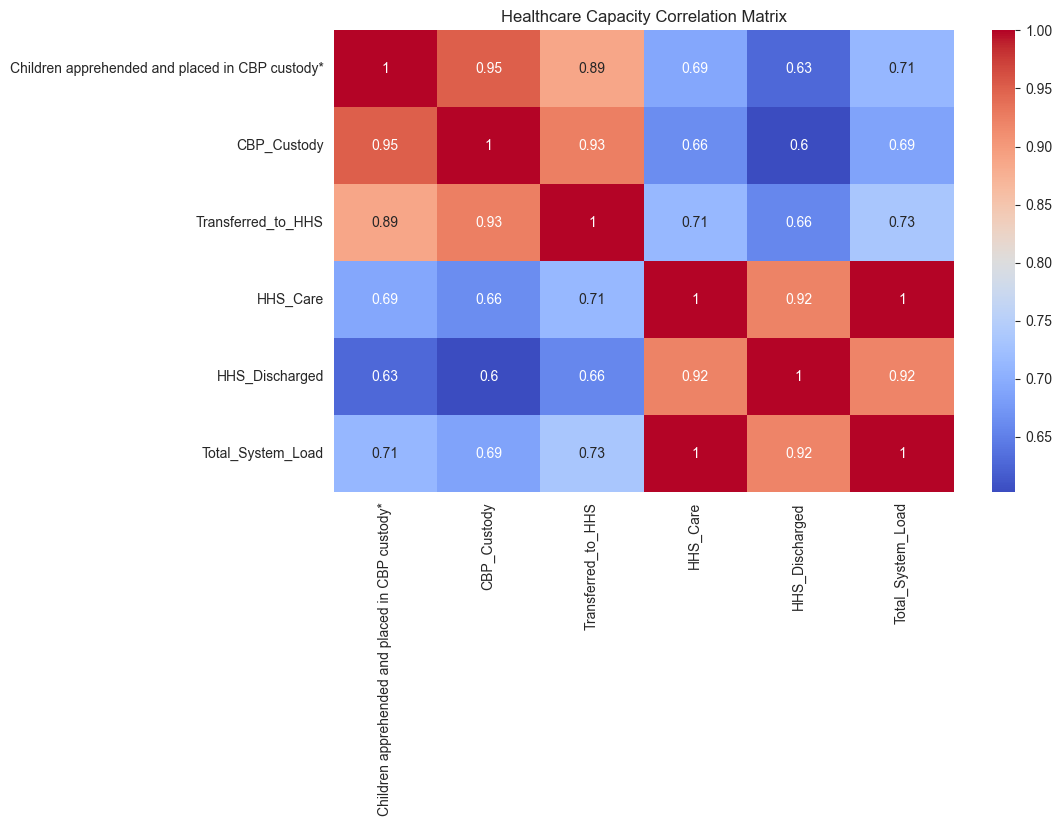

In [187]:
plt.figure(figsize=(10,6))

sns.heatmap(

    df[
        [
            'Children apprehended and placed in CBP custody*',
            'CBP_Custody',
            'Transferred_to_HHS',
            'HHS_Care',
            'HHS_Discharged',
            'Total_System_Load'
        ]
    ].corr(),

    annot=True,

    cmap='coolwarm'
)

plt.title("Healthcare Capacity Correlation Matrix")

plt.show()

In [188]:
df.head()

,Date,Children apprehended and placed in CBP custody*,CBP_Custody,Transferred_to_HHS,HHS_Care,HHS_Discharged,Reporting_Anomaly,Total_System_Load,Net_Daily_Intake,Care_Load_Growth_Rate,Backlog_Indicator,7Day_Load_Avg,14Day_Load_Avg,Stress_Level,Load_Volatility,Month
719,2023-01-12,33.0,53.0,34.0,6566,436.0,Valid,6619.0,-402.0,NaN,NaN,NaN,NaN,Normal,NaN,2023-01
718,2023-01-22,32.0,49.0,39.0,7122,227.0,Valid,7171.0,-188.0,8.339628,NaN,NaN,NaN,Normal,NaN,2023-01
717,2023-01-23,32.0,50.0,39.0,7280,181.0,Valid,7330.0,-142.0,2.217264,NaN,NaN,NaN,Normal,NaN,2023-01
716,2023-01-24,47.0,42.0,47.0,7433,175.0,Anomaly,7475.0,-128.0,1.978172,NaN,NaN,NaN,Normal,NaN,2023-01
715,2023-01-25,20.0,22.0,41.0,7538,180.0,Anomaly,7560.0,-139.0,1.137124,NaN,NaN,NaN,Normal,NaN,2023-01


In [190]:
df.info()   

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 719 to 0
Data columns (total 16 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   CBP_Custody                                      720 non-null    float64       
 3   Transferred_to_HHS                               720 non-null    float64       
 4   HHS_Care                                         720 non-null    int64         
 5   HHS_Discharged                                   720 non-null    float64       
 6   Reporting_Anomaly                                720 non-null    str           
 7   Total_System_Load                                720 non-null    float64       
 8   Net_Daily_Intake                                 72

# Key Insights

In [191]:
print("=========== KEY INSIGHTS ===========")

print()

print("1. System load fluctuates significantly over time.")

print()

print("2. Certain periods show sustained intake pressure.")

print()

print("3. High-load windows indicate operational strain.")

print()

print("4. Backlog accumulation suggests prolonged care burden.")

print()

print("5. Rolling averages reveal persistent stress periods.")

=========== KEY INSIGHTS ===========

1. System load fluctuates significantly over time.

2. Certain periods show sustained intake pressure.

3. High-load windows indicate operational strain.

4. Backlog accumulation suggests prolonged care burden.

5. Rolling averages reveal persistent stress periods.


# Recommendations

In [192]:
print("=========== RECOMMENDATIONS ===========")

print()

print("1. Increase staffing during high-load periods.")

print()

print("2. Expand shelter capacity during surge windows.")

print()

print("3. Improve discharge efficiency to reduce backlog.")

print()

print("4. Monitor rolling averages for early stress detection.")

print()

print("5. Use predictive analytics for future capacity planning.")

=========== RECOMMENDATIONS ===========

1. Increase staffing during high-load periods.

2. Expand shelter capacity during surge windows.

3. Improve discharge efficiency to reduce backlog.

4. Monitor rolling averages for early stress detection.

5. Use predictive analytics for future capacity planning.


Export Final Processed Dataset

In [193]:
df.to_csv(
    "processed_uac_healthcare_analysis.csv",
    index=False
)

In [ ]:
# NOTEBOOK CELL END